# 📊 Data Understanding — Dataset de Resultados de Exámenes de Inglés

**Objetivo:** Análisis exploratorio y validación del dataset de resultados de exámenes de inglés.  
Cubre los controles de calidad recomendados, validación de supuestos, detección de riesgos y generación de un resumen ejecutivo.

**Granularidad:** `IDALUMNE + IDCURS + IDEVALUACIO + MATERIA`  
**Alcance temporal:** 2014-2015 → 2024-2025  
**Idioma:** Inglés (`IDIOMA = 3`)  
**Tipo de curso:** Extensivo de calendario escolar (`IDTIPOCURS = 1`)

---

## 0. Configuración general
Ajusta las variables de esta celda antes de ejecutar el notebook.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Ruta al fichero de datos (ajustar según entorno) ──────────────────────────
RUTA_DATOS = "dataset_ingles.csv"   # ← CAMBIAR por la ruta real

# ── Separador del CSV ─────────────────────────────────────────────────────────
SEPARADOR = ";"

# ── Clave compuesta que debe identificar de forma única cada registro ─────────
CLAVE_UNICA = ["IDALUMNE", "IDCURS", "IDEVALUACIO", "MATERIA"]

# ── Campos demográficos y categóricos a revisar ───────────────────────────────
CAMPOS_DEMOGRAFICOS = ["POBLACIO", "SEXO", "TIPUS_ESCOLA", "TIPOESTUDIANTS", "PROFE"]

# ── Campos de fecha ───────────────────────────────────────────────────────────
CAMPOS_FECHA = ["DATANAIXEMENT", "DATA", "INICI"]

# ── Campos numéricos de resultado ─────────────────────────────────────────────
CAMPOS_RESULTADO = ["RESULT", "TOTAL"]

# ── Rango esperado del ejercicio escolar ──────────────────────────────────────
# NRO_EJERCICIO entre 10 y 20 → cursos 2014-2015 a 2024-2025
EJERCICIO_MIN = "2014-2015"
EJERCICIO_MAX = "2024-2025"

---
## 1. Carga del dataset

In [46]:
try:
    df = pd.read_csv(RUTA_DATOS, sep=SEPARADOR, low_memory=False)
    print(f"✔ Dataset cargado correctamente.")
    print(f"  - Filas:    {df.shape[0]:,}")
    print(f"  - Columnas: {df.shape[1]}")
    print(f"\n  Columnas disponibles:")
    print(list(df.columns))
except FileNotFoundError:
    print(f"✘ ERROR: No se encontró el fichero '{RUTA_DATOS}'.")
    print("  Ajusta la variable RUTA_DATOS con la ruta correcta.")
    raise

✔ Dataset cargado correctamente.
  - Filas:    24,526
  - Columnas: 16

  Columnas disponibles:
['IDALUMNE', 'IDCURS', 'IDEVALUACIO', 'MATERIA', 'RESULT', 'TOTAL', 'POBLACIO', 'DATANAIXEMENT', 'SEXO', 'TIPUS_ESCOLA', 'DATA', 'DESCRIPCIO', 'PROFE', 'TIPOESTUDIANTS', 'EJERCICIO_ESCOLAR', 'INICI']


---
## 2. Visión general del dataset

In [47]:
# Tipos de datos por columna
print("--- Tipos de datos ---")
df.info()

--- Tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24526 entries, 0 to 24525
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   IDALUMNE           24526 non-null  int64 
 1   IDCURS             24526 non-null  int64 
 2   IDEVALUACIO        24526 non-null  int64 
 3   MATERIA            24526 non-null  object
 4   RESULT             24526 non-null  object
 5   TOTAL              24526 non-null  object
 6   POBLACIO           24526 non-null  object
 7   DATANAIXEMENT      24517 non-null  object
 8   SEXO               24526 non-null  object
 9   TIPUS_ESCOLA       24526 non-null  object
 10  DATA               24526 non-null  object
 11  DESCRIPCIO         24526 non-null  object
 12  PROFE              24526 non-null  object
 13  TIPOESTUDIANTS     24526 non-null  object
 14  EJERCICIO_ESCOLAR  24526 non-null  object
 15  INICI              24526 non-null  object
dtypes: int64(3), obje

In [48]:
# Primeras 5 filas del dataset
df.head()

,IDALUMNE,IDCURS,IDEVALUACIO,MATERIA,RESULT,TOTAL,POBLACIO,DATANAIXEMENT,SEXO,TIPUS_ESCOLA,DATA,DESCRIPCIO,PROFE,TIPOESTUDIANTS,EJERCICIO_ESCOLAR,INICI
0,30,788,53,LISTENING,"18,8","68,3",Barcelona,30/10/1998,F,PUBLICA,20/6/2015,TERCER TRIMESTRE,GUY,TEENS,Curs 2014-2015,15/9/2014
1,30,788,50,GRAMMAR,"10,2","64,9",Barcelona,30/10/1998,F,PUBLICA,23/12/2014,PRIMER TRIMESTRE,GUY,TEENS,Curs 2014-2015,15/9/2014
2,30,788,53,WRITING,"14,5","68,3",Barcelona,30/10/1998,F,PUBLICA,20/6/2015,TERCER TRIMESTRE,GUY,TEENS,Curs 2014-2015,15/9/2014
3,30,788,53,READING,"10,4","68,3",Barcelona,30/10/1998,F,PUBLICA,20/6/2015,TERCER TRIMESTRE,GUY,TEENS,Curs 2014-2015,15/9/2014
4,30,788,53,GRAMMAR,"11,1","68,3",Barcelona,30/10/1998,F,PUBLICA,20/6/2015,TERCER TRIMESTRE,GUY,TEENS,Curs 2014-2015,15/9/2014


---
## 3. Control de calidad: Completitud (nulos por campo)

In [50]:
# Porcentaje de nulos por campo, ordenado de mayor a menor
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

df_nulos = pd.DataFrame({
    "Nulos": nulos,
    "% Nulos": pct_nulos
}).sort_values("% Nulos", ascending=False)

print("--- Campos con valores nulos ---")
display(df_nulos[df_nulos["Nulos"] > 0])

if df_nulos["Nulos"].sum() == 0:
    print("✔ No se detectan nulos en el dataset.")

--- Campos con valores nulos ---


,Nulos,% Nulos
DATANAIXEMENT,9,0.04


In [51]:
df.isnull().sum()


IDALUMNE             0
IDCURS               0
IDEVALUACIO          0
MATERIA              0
RESULT               0
TOTAL                0
POBLACIO             0
DATANAIXEMENT        9
SEXO                 0
TIPUS_ESCOLA         0
DATA                 0
DESCRIPCIO           0
PROFE                0
TIPOESTUDIANTS       0
EJERCICIO_ESCOLAR    0
INICI                0
dtype: int64

In [52]:
# Completitud de campos demográficos y categóricos
# Umbral de alerta: > 5% de nulos
print("--- Completitud de campos demográficos ---")
for campo in CAMPOS_DEMOGRAFICOS:
    if campo in df.columns:
        pct = df[campo].isnull().mean() * 100
        estado = "⚠ REVISAR" if pct > 5 else "✔ OK"
        print(f"  {campo:<20} → {pct:.2f}% nulos  {estado}")

print("\n--- Completitud de campos de fecha ---")
# Umbral más estricto para fechas: > 1% de nulos
for campo in CAMPOS_FECHA:
    if campo in df.columns:
        pct = df[campo].isnull().mean() * 100
        estado = "⚠ REVISAR" if pct > 1 else "✔ OK"
        print(f"  {campo:<20} → {pct:.2f}% nulos  {estado}")

--- Completitud de campos demográficos ---
  POBLACIO             → 0.00% nulos  ✔ OK
  SEXO                 → 0.00% nulos  ✔ OK
  TIPUS_ESCOLA         → 0.00% nulos  ✔ OK
  TIPOESTUDIANTS       → 0.00% nulos  ✔ OK
  PROFE                → 0.00% nulos  ✔ OK

--- Completitud de campos de fecha ---
  DATANAIXEMENT        → 0.04% nulos  ✔ OK
  DATA                 → 0.00% nulos  ✔ OK
  INICI                → 0.00% nulos  ✔ OK


---
## 4. Control de calidad: Unicidad de la clave compuesta

> La clave compuesta `IDALUMNE + IDCURS + IDEVALUACIO + MATERIA` debe identificar de forma única cada registro del dataset.

In [53]:
# Verificar que todos los campos de la clave existen en el dataset
clave_existente = [c for c in CLAVE_UNICA if c in df.columns]

if len(clave_existente) == len(CLAVE_UNICA):
    total_filas = len(df)
    filas_unicas = df[clave_existente].drop_duplicates().shape[0]
    duplicados = total_filas - filas_unicas

    print(f"  Total de filas:          {total_filas:,}")
    print(f"  Combinaciones únicas:    {filas_unicas:,}")
    print(f"  Duplicados detectados:   {duplicados:,}")

    if duplicados == 0:
        print("  ✔ La clave compuesta identifica de forma única cada registro.")
    else:
        print(f"  ⚠ ALERTA: Se detectan {duplicados:,} duplicados. Revisar antes de analizar.")
        # Mostrar muestra de registros duplicados para facilitar diagnóstico
        df_dup = df[df.duplicated(subset=clave_existente, keep=False)]
        print("\n  Muestra de registros duplicados (primeras 10 filas):")
        display(df_dup[clave_existente].head(10))
else:
    campos_faltantes = set(CLAVE_UNICA) - set(df.columns)
    print(f"  ⚠ Faltan campos de la clave compuesta: {campos_faltantes}")

  Total de filas:          24,526
  Combinaciones únicas:    24,526
  Duplicados detectados:   0
  ✔ La clave compuesta identifica de forma única cada registro.


---
## 5. Control de calidad: Validez de valores en campos de resultado

In [54]:
# Revisión de rangos, ceros residuales y valores negativos en RESULT y TOTAL
# El filtro de extracción debería haber eliminado todos los ceros.
# Si aparecen ceros, validar semántica con negocio.

global_numeric_stats = df[CAMPOS_RESULTADO].describe().T


display(global_numeric_stats.head(10))

# Convertir RESULT y TOTAL a numérico (reemplazar coma por punto)
for campo in CAMPOS_RESULTADO:
    if campo in df.columns:
        df[campo] = df[campo].astype(str).str.replace(",", ".").astype(float)

for campo in CAMPOS_RESULTADO:
    if campo in df.columns:
        print(f"\n{'='*50}")
        print(f"  Campo: {campo}")
        print(f"{'='*50}")
        print(df[campo].describe())

        # Detección de ceros residuales
        n_ceros = (df[campo] == 0).sum()
        if n_ceros > 0:
            print(f"\n  ⚠ ALERTA: {n_ceros:,} registros con valor 0 en {campo}. Validar semántica.")
        else:
            print(f"\n  ✔ Sin valores 0 (filtro aplicado correctamente).")

        # Detección de valores negativos (no esperados en resultados de examen)
        n_neg = (df[campo] < 0).sum()
        if n_neg > 0:
            print(f"  ⚠ ALERTA: {n_neg:,} registros con valores negativos. Revisar.")

,count,unique,top,freq
RESULT,24526,191,14,2577
TOTAL,24526,570,"64,6",294



  Campo: RESULT
count    24526.000000
mean        13.476172
std          3.182052
min          0.400000
25%         12.000000
50%         13.500000
75%         15.000000
max         33.800000
Name: RESULT, dtype: float64

  ✔ Sin valores 0 (filtro aplicado correctamente).

  Campo: TOTAL
count    24526.000000
mean        66.700709
std         10.497079
min          3.800000
25%         60.500000
50%         67.000000
75%         74.100000
max         95.000000
Name: TOTAL, dtype: float64

  ✔ Sin valores 0 (filtro aplicado correctamente).


---
## 6. Riesgo de doble conteo: campo TOTAL

> ⚠️ **Riesgo crítico:** El campo `TOTAL` está a nivel de **evaluación**, pero el dataset está a nivel de **materia**. El mismo valor de `TOTAL` puede repetirse en múltiples filas del mismo alumno. **Nunca agregar `TOTAL` sin deduplicar previamente.**

In [55]:
# Cuantificar cuántas materias tiene cada evaluación (alumno + curso + evaluación)
# Si n_materias > 1, el campo TOTAL está repetido en esas filas.

if all(c in df.columns for c in ["IDALUMNE", "IDCURS", "IDEVALUACIO", "TOTAL", "MATERIA"]):
    clave_eval = ["IDALUMNE", "IDCURS", "IDEVALUACIO"]
    materias_por_eval = df.groupby(clave_eval)["MATERIA"].count().reset_index()
    materias_por_eval.columns = clave_eval + ["n_materias"]

    print("  Distribución del número de materias por evaluación:")
    display(materias_por_eval["n_materias"].value_counts().sort_index().rename("Evaluaciones").to_frame())

    pct_multi = (materias_por_eval["n_materias"] > 1).mean() * 100
    print(f"\n  {pct_multi:.1f}% de las evaluaciones tienen más de una materia.")
    print("\n  ⚠ Para analizar TOTAL, deduplicar SIEMPRE por IDALUMNE + IDCURS + IDEVALUACIO.")
else:
    print("  ⚠ No se encuentran todos los campos necesarios para esta validación.")

  Distribución del número de materias por evaluación:


,Evaluaciones
n_materias,
1,20
2,6
3,32
4,257
5,4674



  99.6% de las evaluaciones tienen más de una materia.

  ⚠ Para analizar TOTAL, deduplicar SIEMPRE por IDALUMNE + IDCURS + IDEVALUACIO.


In [56]:
# Cuantificar cuantos tienen las 5 materias
# Primero, obtener los grupos que tienen exactamente 5 materias
grupos_con_5_materias = df.groupby(["IDALUMNE", "IDCURS", "IDEVALUACIO"])["MATERIA"].count()
grupos_validos = grupos_con_5_materias[grupos_con_5_materias == 5].index

# Luego, filtrar el DataFrame para mantener solo esos registros
df_filtrado = df[df.set_index(["IDALUMNE", "IDCURS", "IDEVALUACIO"]).index.isin(grupos_validos)]

Materias_5=df_filtrado.shape[0] * 100 / len(df)
print(f"\n  {Materias_5:.1f}% de las evaluaciones tienen las 5 materias.")


  95.3% de las evaluaciones tienen las 5 materias.


In [57]:
df_filtrado.shape

(23370, 16)

---
## 7. Dominio de variables categóricas

In [58]:
# Revisión de los valores únicos que toman las variables categóricas clave.
# Permite detectar inconsistencias, categorías no normalizadas o valores inesperados.

campos_categoricos = ["MATERIA", "SEXO", "TIPUS_ESCOLA", "TIPOESTUDIANTS", "EJERCICIO_ESCOLAR"]

for campo in campos_categoricos:
    if campo in df.columns:
        valores = df[campo].value_counts(dropna=False)
        print(f"\n{'─'*50}")
        print(f"  {campo}  ({df[campo].nunique(dropna=True)} valores únicos)")
        print(f"{'─'*50}")
        # Mostrar hasta 15 valores más frecuentes
        display(valores.head(15).rename("Frecuencia").to_frame())
        if len(valores) > 15:
            print(f"  ... y {len(valores) - 15} valores más.")


──────────────────────────────────────────────────
  MATERIA  (5 valores únicos)
──────────────────────────────────────────────────


,Frecuencia
MATERIA,
GRAMMAR,4967
READING,4946
LISTENING,4941
SPEAKING,4838
WRITING,4834



──────────────────────────────────────────────────
  SEXO  (2 valores únicos)
──────────────────────────────────────────────────


,Frecuencia
SEXO,
F,13979
M,10547



──────────────────────────────────────────────────
  TIPUS_ESCOLA  (3 valores únicos)
──────────────────────────────────────────────────


,Frecuencia
TIPUS_ESCOLA,
PUBLICA,11108
FINALITZAT,8390
NO PUBLICA,5028



──────────────────────────────────────────────────
  TIPOESTUDIANTS  (4 valores únicos)
──────────────────────────────────────────────────


,Frecuencia
TIPOESTUDIANTS,
TEENS,8548
ADULTS,6525
ADULTS & TEENS,6065
KIDS,3388



──────────────────────────────────────────────────
  EJERCICIO_ESCOLAR  (11 valores únicos)
──────────────────────────────────────────────────


,Frecuencia
EJERCICIO_ESCOLAR,
Curs 2014-2015,3429
Curs 2015-2016,3146
Curs 2016-2017,3021
Curs 2017-2018,2409
Curs 2018-2019,2051
Curs 2020-2021,1980
Curs 2023-2024,1919
Curs 2021-2022,1850
Curs 2022-2023,1844


---
## 8. Integridad temporal

In [59]:
# Conversión y validación de campos de fecha.
# Las fechas que no se puedan parsear se convertirán a NaT (nulo de fecha).

print("--- Validación de fechas ---")
for campo in CAMPOS_FECHA:
    if campo in df.columns:
        df[campo] = pd.to_datetime(df[campo], errors="coerce")
        n_invalidos = df[campo].isnull().sum()
        print(f"  {campo:<20}: {n_invalidos:,} fechas no válidas/nulas.")
        if n_invalidos == 0:
            print(f"    Rango: {df[campo].min().date()} → {df[campo].max().date()}")

--- Validación de fechas ---
  DATANAIXEMENT       : 9 fechas no válidas/nulas.
  DATA                : 0 fechas no válidas/nulas.
    Rango: 2014-12-23 → 2025-06-21
  INICI               : 0 fechas no válidas/nulas.
    Rango: 2014-09-15 → 2024-09-15


In [62]:
# Derivar la edad del alumno en el momento de la evaluación.
# Permite detectar fechas de nacimiento erróneas o evaluaciones mal fechadas.

if "DATANAIXEMENT" in df.columns and "DATA" in df.columns:
    df["EDAD_EN_EVALUACION"] = (
        (df["DATA"] - df["DATANAIXEMENT"]).dt.days / 365.25
    ).round(1)

    print("  Estadísticas de edad en el momento de la evaluación:")
    display(df["EDAD_EN_EVALUACION"].describe().to_frame())

    # Umbrales de edad fuera de rango esperado para alumnos de inglés
    n_menores = (df["EDAD_EN_EVALUACION"] < 8).sum()
    n_mayores = (df["EDAD_EN_EVALUACION"] > 70).sum()
    if n_menores > 0 or n_mayores > 0:
        print(f"\n  ⚠ Edades sospechosas: {n_menores} menores de 8 años, {n_mayores} mayores de 70.")
    else:
        print("  ✔ Rango de edades aparentemente coherente.")

  Estadísticas de edad en el momento de la evaluación:


,EDAD_EN_EVALUACION
count,24517.000000
mean,20.092409
std,10.414143
min,0.100000
25%,14.200000
50%,16.700000
75%,21.500000
max,73.000000



  ⚠ Edades sospechosas: 227 menores de 8 años, 15 mayores de 70.


In [ ]:
# Verificar qué ejercicios escolares están presentes en el dataset.
# Deben estar dentro del rango 2014-2015 → 2024-2025.

if "EJERCICIO_ESCOLAR" in df.columns:
    print("  Ejercicios escolares presentes en el dataset:")
    display(
        df["EJERCICIO_ESCOLAR"].value_counts()
          .sort_index()
          .rename("Registros")
          .to_frame()
    )

---
## 9. Análisis exploratorio: Distribución de resultados

In [63]:
# Media del resultado parcial por materia
if "RESULT" in df.columns and "MATERIA" in df.columns:
    media_materia = df.groupby("MATERIA")["RESULT"].mean().sort_values(ascending=False)
    print("  Media de RESULT por MATERIA:")
    display(media_materia.round(2).rename("Media RESULT").to_frame())

  Media de RESULT por MATERIA:


,Media RESULT
MATERIA,
LISTENING,14.65
READING,14.32
SPEAKING,13.43
WRITING,13.20
GRAMMAR,11.78


In [64]:
# Estadísticas del resultado total, DEDUPLICADO por alumno + curso + evaluación.
# Es obligatorio deduplicar antes de analizar TOTAL (ver sección 6).

if all(c in df.columns for c in ["IDALUMNE", "IDCURS", "IDEVALUACIO", "TOTAL"]):
    df_total = df.drop_duplicates(subset=["IDALUMNE", "IDCURS", "IDEVALUACIO"])
    print(f"  Estadísticas de TOTAL (deduplicado, n={len(df_total):,} evaluaciones):")
    display(df_total["TOTAL"].describe().to_frame())

  Estadísticas de TOTAL (deduplicado, n=4,989 evaluaciones):


,TOTAL
count,4989.000000
mean,66.249068
std,11.208735
min,3.800000
25%,60.100000
50%,66.900000
75%,74.000000
max,95.000000


In [65]:
# Media de TOTAL por sexo (sobre dataset deduplicado)
if "SEXO" in df.columns and "TOTAL" in df_total.columns:
    print("  Media de TOTAL por SEXO:")
    display(df_total.groupby("SEXO")["TOTAL"].mean().round(2).rename("Media TOTAL").to_frame())

  Media de TOTAL por SEXO:


,Media TOTAL
SEXO,
F,66.15
M,66.38


In [66]:
# Evolución de la media de TOTAL por ejercicio escolar (sobre dataset deduplicado)
if "EJERCICIO_ESCOLAR" in df.columns and "TOTAL" in df_total.columns:
    evolucion = df_total.groupby("EJERCICIO_ESCOLAR")["TOTAL"].mean().sort_index()
    print("  Media de TOTAL por EJERCICIO_ESCOLAR:")
    display(evolucion.round(2).rename("Media TOTAL").to_frame())

  Media de TOTAL por EJERCICIO_ESCOLAR:


,Media TOTAL
EJERCICIO_ESCOLAR,
Curs 2014-2015,69.17
Curs 2015-2016,66.08
Curs 2016-2017,65.27
Curs 2017-2018,64.13
Curs 2018-2019,67.21
Curs 2019-2020,64.10
Curs 2020-2021,66.20
Curs 2021-2022,63.43
Curs 2022-2023,68.09


---
## 10. Visualizaciones básicas

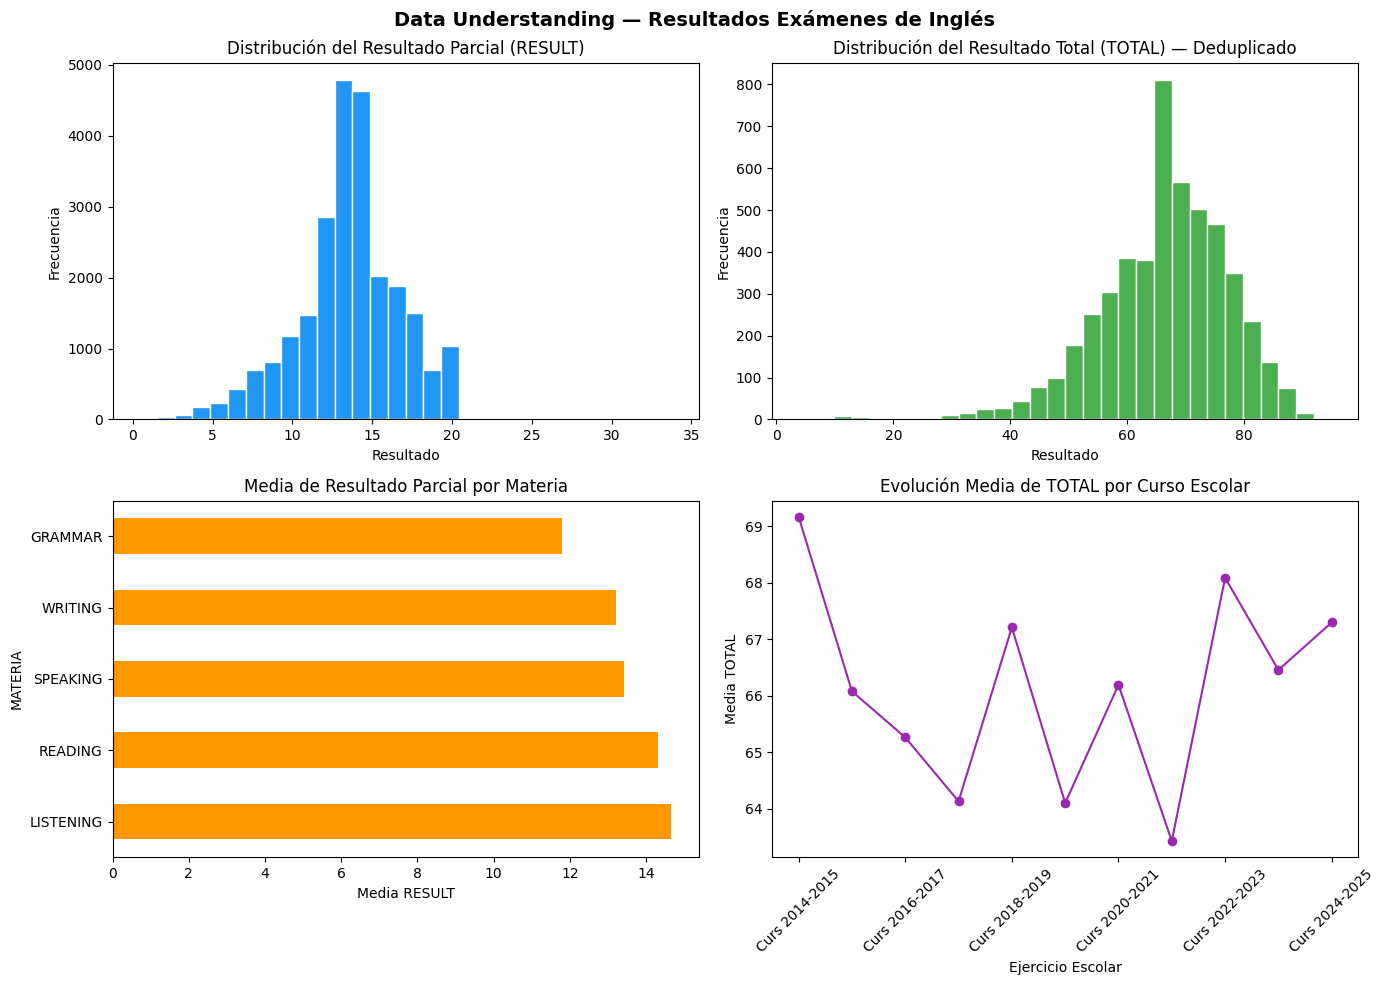

✔ Visualizaciones guardadas en 'data_understanding_resultados.png'.


In [67]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Data Understanding — Resultados Exámenes de Inglés", fontsize=14, fontweight="bold")

# ── Gráfico 1: Distribución del resultado parcial (RESULT) ───────────────────
if "RESULT" in df.columns:
    axes[0, 0].hist(df["RESULT"].dropna(), bins=30, color="#2196F3", edgecolor="white")
    axes[0, 0].set_title("Distribución del Resultado Parcial (RESULT)")
    axes[0, 0].set_xlabel("Resultado")
    axes[0, 0].set_ylabel("Frecuencia")

# ── Gráfico 2: Distribución del resultado total (TOTAL, deduplicado) ─────────
if "TOTAL" in df.columns:
    axes[0, 1].hist(df_total["TOTAL"].dropna(), bins=30, color="#4CAF50", edgecolor="white")
    axes[0, 1].set_title("Distribución del Resultado Total (TOTAL) — Deduplicado")
    axes[0, 1].set_xlabel("Resultado")
    axes[0, 1].set_ylabel("Frecuencia")

# ── Gráfico 3: Media de RESULT por MATERIA ────────────────────────────────────
if "RESULT" in df.columns and "MATERIA" in df.columns:
    media_materia.plot(kind="barh", ax=axes[1, 0], color="#FF9800")
    axes[1, 0].set_title("Media de Resultado Parcial por Materia")
    axes[1, 0].set_xlabel("Media RESULT")

# ── Gráfico 4: Evolución de TOTAL por ejercicio escolar ───────────────────────
if "EJERCICIO_ESCOLAR" in df.columns and "TOTAL" in df.columns:
    evolucion.plot(kind="line", ax=axes[1, 1], marker="o", color="#9C27B0")
    axes[1, 1].set_title("Evolución Media de TOTAL por Curso Escolar")
    axes[1, 1].set_xlabel("Ejercicio Escolar")
    axes[1, 1].set_ylabel("Media TOTAL")
    axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("data_understanding_resultados.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Visualizaciones guardadas en 'data_understanding_resultados.png'.")

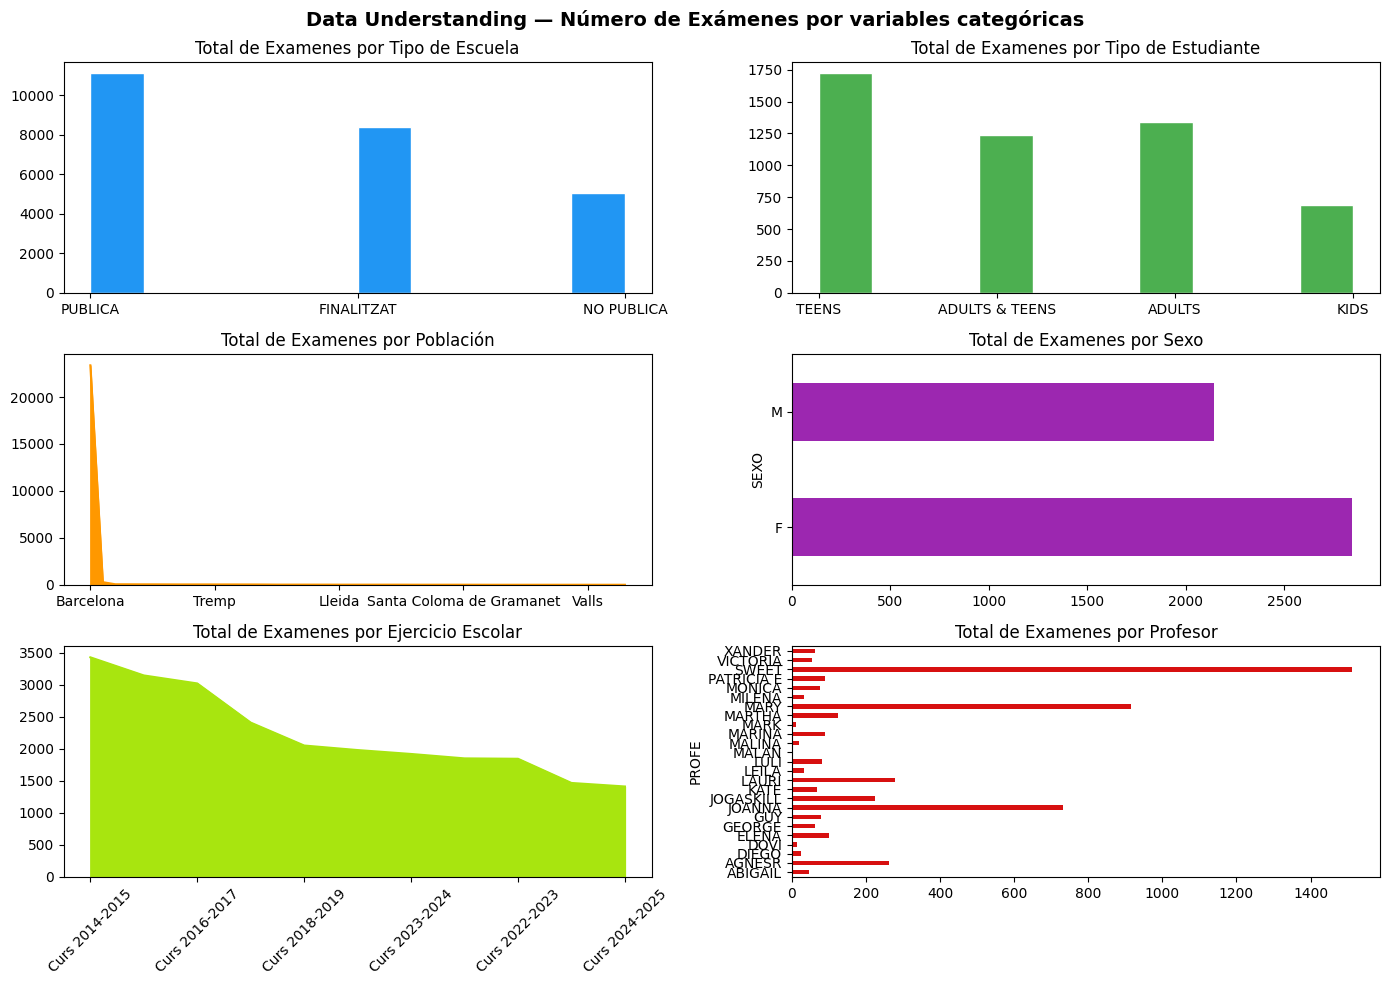

✔ Visualizaciones guardadas en 'data_understanding_resultados2.png'.


In [68]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Data Understanding — Número de Exámenes por variables categóricas", fontsize=14, fontweight="bold")

# ── Gráfico 1: Total de examenes por tipo de escuela ───────────────────
if "RESULT" in df.columns:
    axes[0, 0].hist(df["TIPUS_ESCOLA"].dropna(), bins=10, color="#2196F3", edgecolor="white")
    axes[0, 0].set_title("Total de Examenes por Tipo de Escuela")
    

# ── Gráfico 2: Total de examenes por tipo de estudiante ─────────
if "TOTAL" in df.columns:
    axes[0, 1].hist(df_total["TIPOESTUDIANTS"].dropna(), bins=10, color="#4CAF50", edgecolor="white")
    axes[0, 1].set_title("Total de Examenes por Tipo de Estudiante")
    

# ── Gráfico 3: Total de examenes por Población ────────────────────────────────────
if "RESULT" in df.columns and "POBLACIO" in df.columns:
    media_poblacion = df.groupby("POBLACIO")["RESULT"].count().sort_values(ascending=False)
    media_poblacion.plot(kind="area", ax=axes[1, 0], color="#FF9800")
    axes[1, 0].set_title("Total de Examenes por Población")
    axes[1, 0].set_xlabel('')

# ── Gráfico 4: Media de TOTAL por SEXO ───────────────────────
if "SEXO" in df_total.columns and "RESULT" in df_total.columns:
    media_sexo = df_total.groupby("SEXO")["TOTAL"].count()
    media_sexo.plot(kind="barh", ax=axes[1, 1], color="#9C27B0")
    axes[1, 1].set_title("Total de Examenes por Sexo")
    

# ── Gráfico 5: Total de examenes por EJERCICIO_ESCOLAR ────────────────────────────────────
if "RESULT" in df.columns and "EJERCICIO_ESCOLAR" in df.columns:
    media_poblacion = df.groupby("EJERCICIO_ESCOLAR")["RESULT"].count().sort_values(ascending=False)
    media_poblacion.plot(kind="area", ax=axes[2, 0], color="#A8E50F")
    axes[2, 0].set_title("Total de Examenes por Ejercicio Escolar")
    axes[2, 0].set_xlabel('')    
    axes[2, 0].tick_params(axis='x', rotation=45)

# ── Gráfico 6: Total de examenes por PROFE ───────────────────────
if "PROFE" in df_total.columns and "TOTAL" in df_total.columns:
    media_sexo = df_total.groupby("PROFE")["TOTAL"].count()
    media_sexo.plot(kind="barh", ax=axes[2, 1], color="#D71010")
    axes[2, 1].set_title("Total de Examenes por Profesor")
    

plt.tight_layout()
plt.savefig("data_understanding_resultados.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Visualizaciones guardadas en 'data_understanding_resultados2.png'.")

---
Coorelaciones

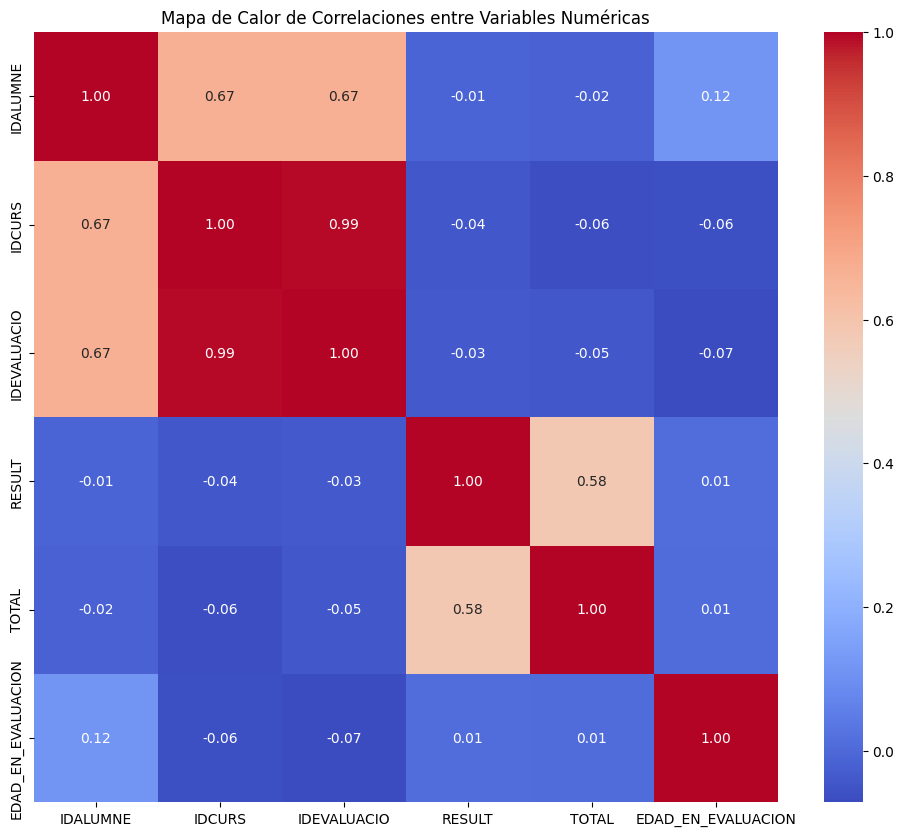

In [75]:
#Detecten correlaciones entre variables.
df_corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Mapa de Calor de Correlaciones entre Variables Numéricas")
plt.show()

---
## 11. Resumen ejecutivo de calidad del dataset

In [69]:
# KPIs de calidad del dataset en una sola tabla de referencia rápida

resumen = {
    "Total de registros": len(df),
    "Campos disponibles": df.shape[1],
    "Campos con nulos": int((df.isnull().sum() > 0).sum()),
    "Duplicados en clave compuesta": duplicados if "duplicados" in dir() else "No calculado",
    "Valores 0 en RESULT": int((df["RESULT"] == 0).sum()) if "RESULT" in df.columns else "N/A",
    "Valores 0 en TOTAL": int((df["TOTAL"] == 0).sum()) if "TOTAL" in df.columns else "N/A",
    "Ejercicios escolares distintos": df["EJERCICIO_ESCOLAR"].nunique() if "EJERCICIO_ESCOLAR" in df.columns else "N/A",
    "Materias distintas": df["MATERIA"].nunique() if "MATERIA" in df.columns else "N/A",
    "Alumnos distintos (IDALUMNE)": df["IDALUMNE"].nunique() if "IDALUMNE" in df.columns else "N/A",
    "Evaluaciones únicas (deduplicadas)": len(df_total) if "df_total" in dir() else "N/A",
}

df_resumen = pd.DataFrame.from_dict(resumen, orient="index", columns=["Valor"])
display(df_resumen)

,Valor
Total de registros,24526
Campos disponibles,17
Campos con nulos,2
Duplicados en clave compuesta,0
Valores 0 en RESULT,0
Valores 0 en TOTAL,0
Ejercicios escolares distintos,11
Materias distintas,5
Alumnos distintos (IDALUMNE),983
Evaluaciones únicas (deduplicadas),4989


In [70]:
# Checklist de próximos pasos antes de pasar al análisis formal

proximos_pasos = [
    "1. Validar semántica de MATERIA, PROFE, TIPOESTUDIANTS, TIPUS_ESCOLA con negocio",
    "2. Confirmar que valor 0 = ausencia de resultado (no nota válida) con el diccionario de datos",
    "3. Resolver duplicados en clave compuesta si los hay",
    "4. Normalizar campos categóricos con nulos o valores inconsistentes",
    "5. Deduplicar por IDALUMNE + IDCURS + IDEVALUACIO SIEMPRE antes de analizar TOTAL",
    "6. Derivar variables analíticas: tramos de edad, segmentos geográficos, etc.",
    "7. Separar conceptualmente los análisis a nivel de materia y a nivel de evaluación",
]

print("\n✔ Data Understanding completado.\n")
print("  PRÓXIMOS PASOS:")
for paso in proximos_pasos:
    print(f"  {paso}")


✔ Data Understanding completado.

  PRÓXIMOS PASOS:
  1. Validar semántica de MATERIA, PROFE, TIPOESTUDIANTS, TIPUS_ESCOLA con negocio
  2. Confirmar que valor 0 = ausencia de resultado (no nota válida) con el diccionario de datos
  3. Resolver duplicados en clave compuesta si los hay
  4. Normalizar campos categóricos con nulos o valores inconsistentes
  5. Deduplicar por IDALUMNE + IDCURS + IDEVALUACIO SIEMPRE antes de analizar TOTAL
  6. Derivar variables analíticas: tramos de edad, segmentos geográficos, etc.
  7. Separar conceptualmente los análisis a nivel de materia y a nivel de evaluación
